In [ ]:
pip install shap

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import shap

In [2]:
#load the data
df = pd.read_csv('/content/Economic Indicators And Inflation.csv')
df.head()

,Country,Year,GDP (in billion USD),Inflation Rate (%),Unemployment Rate (%),Economic Growth (%)
0,USA,2010,15000,1.64,9.63,2.55
1,USA,2011,15500,3.16,8.94,1.53
2,USA,2012,16000,2.07,8.10,2.28
3,USA,2013,16500,1.50,7.70,1.84
4,USA,2014,17000,1.62,7.25,2.53


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 304 non-null    object 
 1    Year                   304 non-null    int64  
 2    GDP (in billion USD)   304 non-null    int64  
 3    Inflation Rate (%)     304 non-null    float64
 4    Unemployment Rate (%)  304 non-null    float64
 5    Economic Growth (%)    304 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 14.4+ KB


In [4]:
df.isnull().sum()

,0
Country,0
Year,0
GDP (in billion USD),0
Inflation Rate (%),0
Unemployment Rate (%),0
Economic Growth (%),0


In [5]:
df.duplicated().sum()

np.int64(0)

In [15]:
for col in df.columns:
    print(repr(col))


'Country'
' Year'
' GDP (in billion USD)'
' Inflation Rate (%)'
' Unemployment Rate (%)'
' Economic Growth (%)'


In [6]:
df.describe()

,Year,GDP (in billion USD),Inflation Rate (%),Unemployment Rate (%),Economic Growth (%)
count,304.000000,304.000000,304.000000,304.000000,304.000000
mean,2017.500000,3173.934211,35.531776,6.805493,3.391349
std,4.617373,4365.913537,131.757515,6.687968,3.626414
min,2010.000000,1.000000,-1.200000,1.600000,-14.000000
25%,2013.750000,475.000000,1.635000,4.275000,1.700000
50%,2017.500000,1900.000000,3.300000,5.400000,2.900000
75%,2021.250000,3425.000000,5.857500,7.800000,5.905000
max,2025.000000,22500.000000,857.000000,85.500000,13.700000


In [7]:
df.head()

,Country,Year,GDP (in billion USD),Inflation Rate (%),Unemployment Rate (%),Economic Growth (%)
0,USA,2010,15000,1.64,9.63,2.55
1,USA,2011,15500,3.16,8.94,1.53
2,USA,2012,16000,2.07,8.10,2.28
3,USA,2013,16500,1.50,7.70,1.84
4,USA,2014,17000,1.62,7.25,2.53


# VISUALIZARION

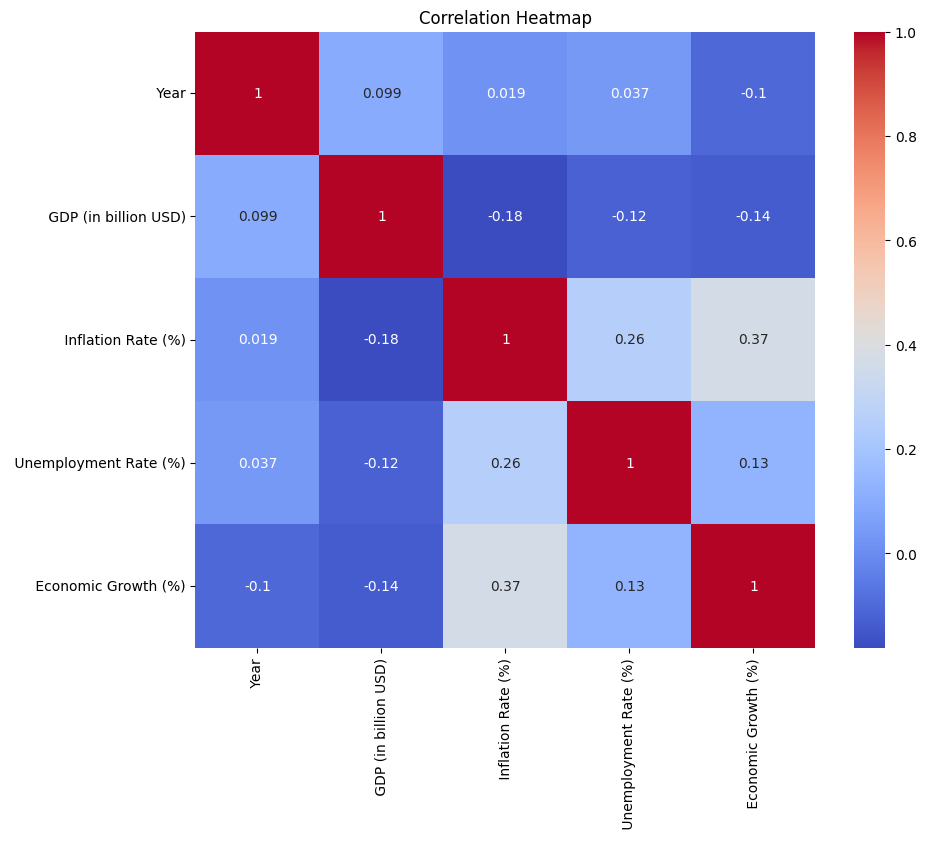

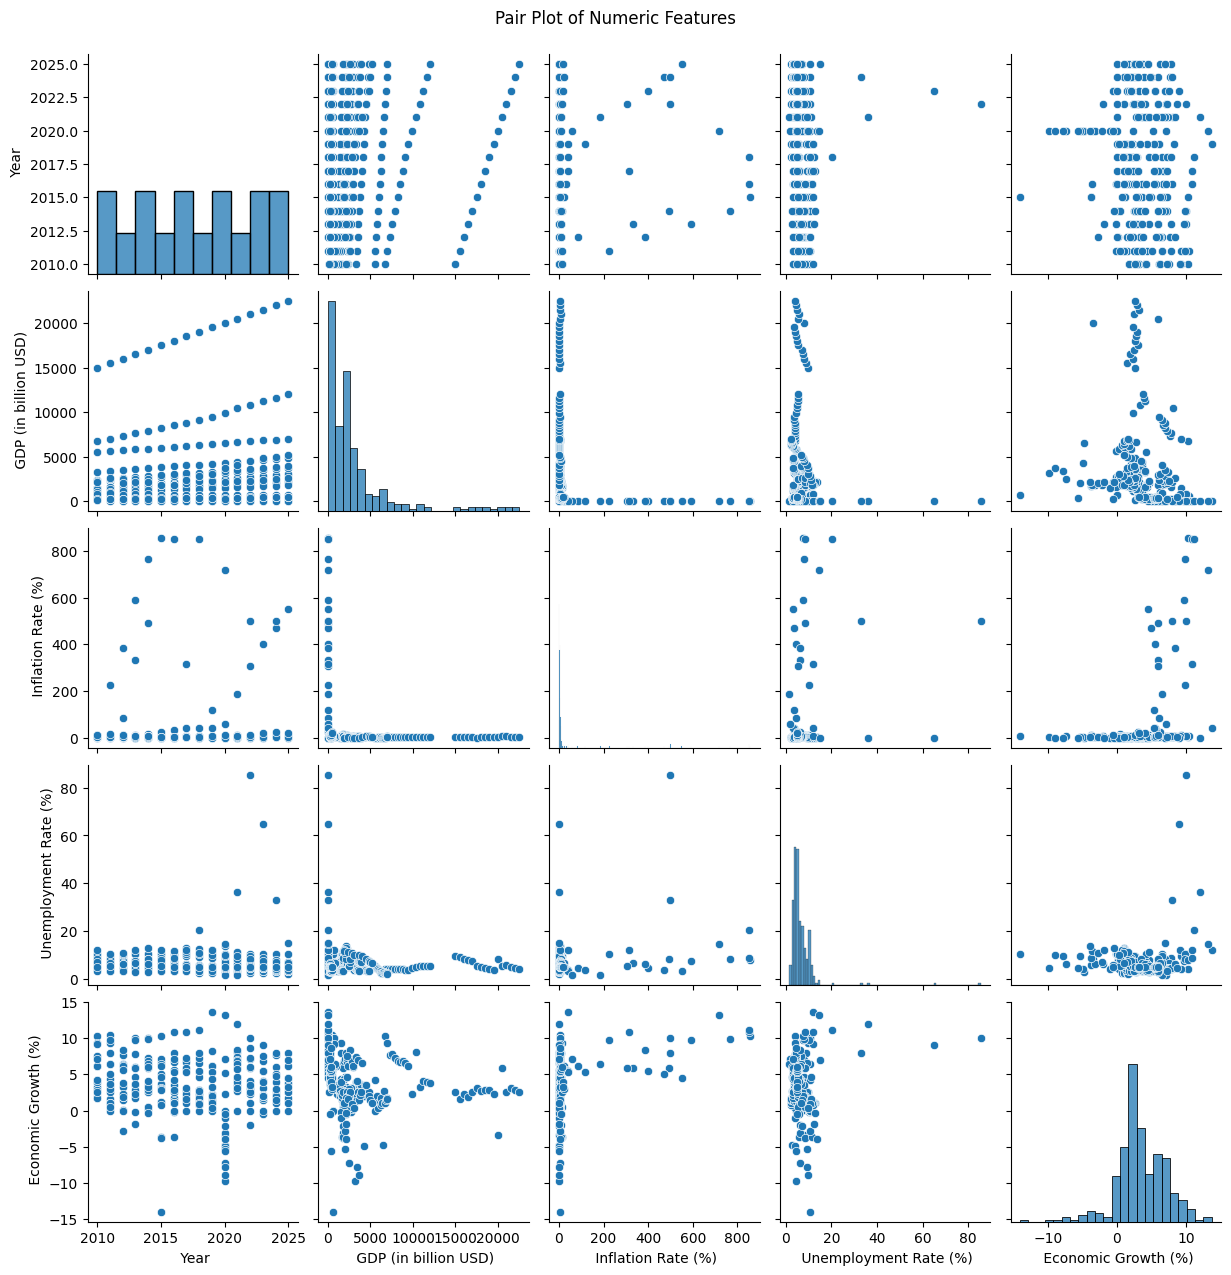

In [23]:
## import library
import matplotlib.pyplot as plt
import seaborn as sns


## Numeric data for correlation and pair plots
numeric_df = df.select_dtypes(include=[np.number])

## Correlation Heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

## Pair Plot
sns.pairplot(numeric_df.dropna())
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

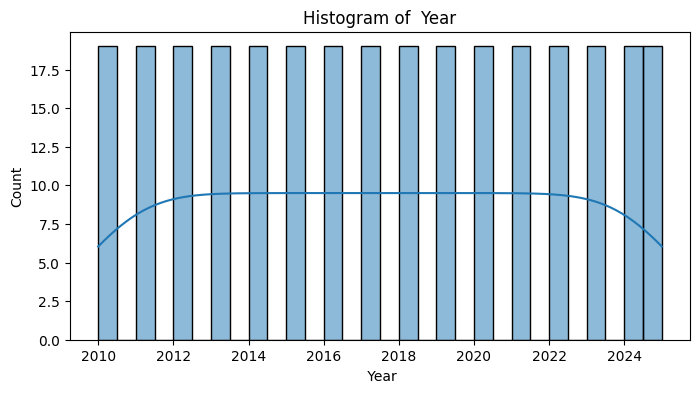

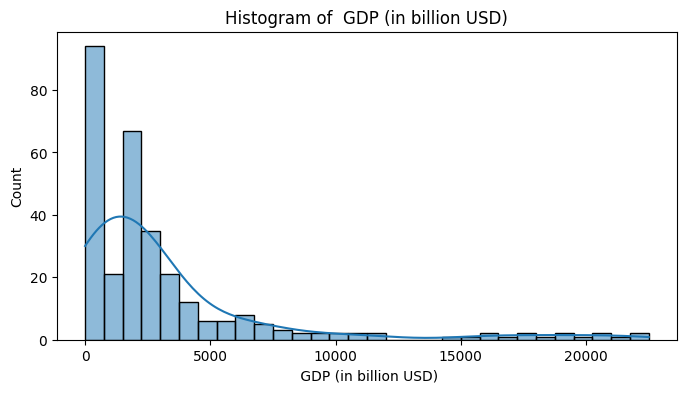

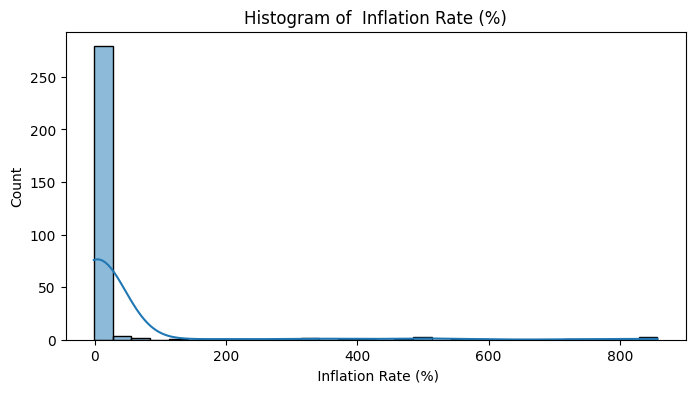

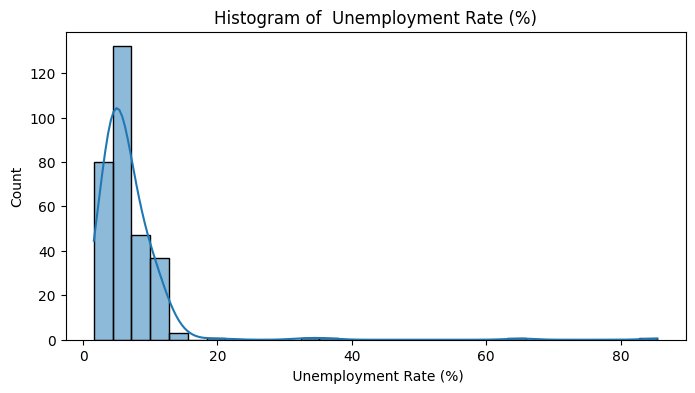

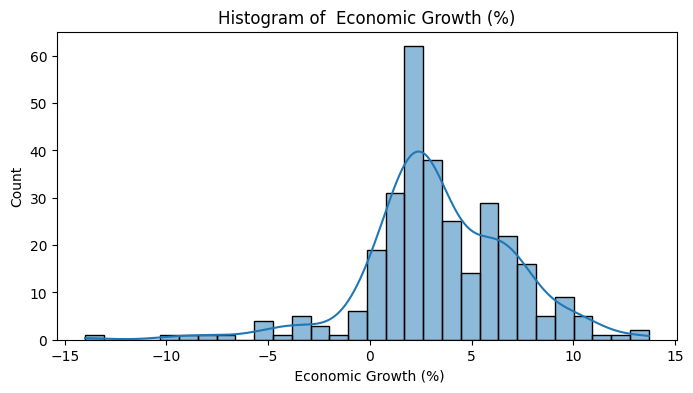

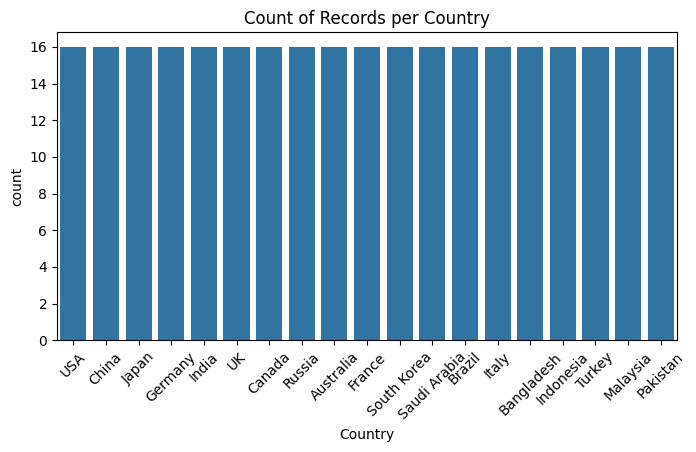

In [22]:
## Histograms for numeric columns
numeric_columns = numeric_df.columns
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(numeric_df[col].dropna(), kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.show()

## Pie Chart (using countplot) for Country counts
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Country')
plt.title('Count of Records per Country')
plt.xticks(rotation=45)
plt.show()


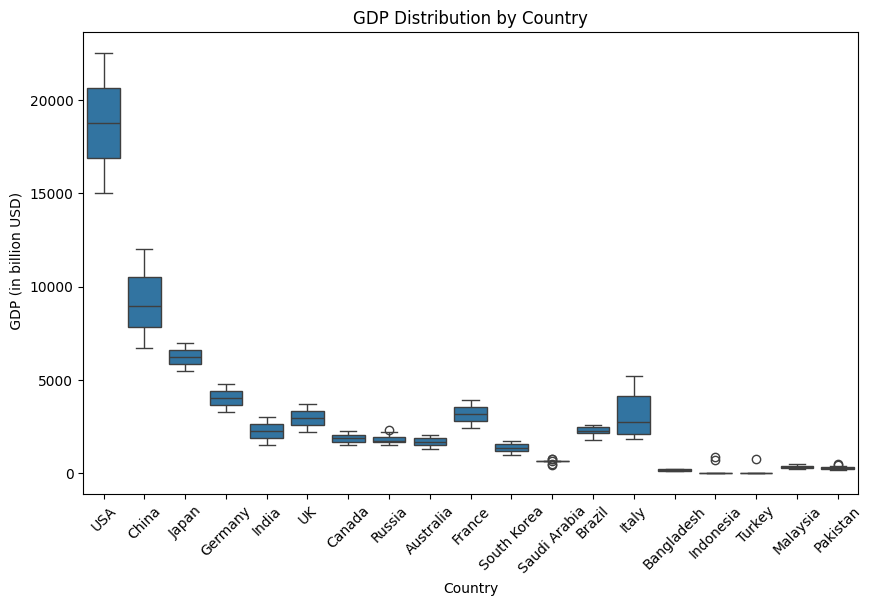

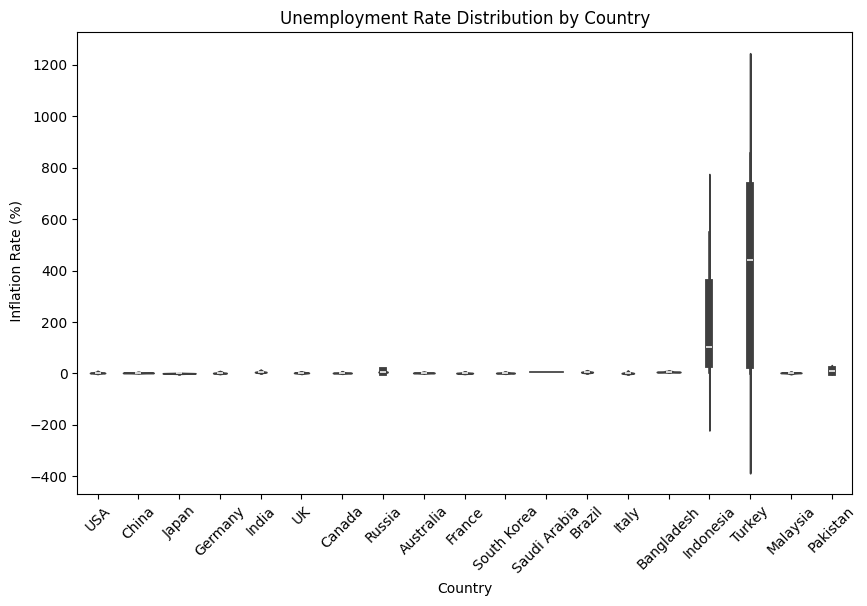

In [21]:
## Box Plot for economic indicators by Country
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Country', y=' GDP (in billion USD)')
plt.title('GDP Distribution by Country')
plt.xticks(rotation=45)
plt.show()

## Violin Plot for Unemployment Rate by Country
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Country', y=' Inflation Rate (%)')
plt.title('Unemployment Rate Distribution by Country')
plt.xticks(rotation=45)
plt.show()

# PREPROCESSING AND SPLIT FEATURES

In [24]:
#Clean Column Names

df.columns = df.columns.str.strip()

In [25]:
#Encode Country Names

le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])

In [26]:
# Display the mapping of countries to their label encoded values
country_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Country Label Encoding Mapping:")
for country, code in country_mapping.items():
    print(f"{country}: {code}")


Country Label Encoding Mapping:
Australia: 0
Bangladesh: 1
Brazil: 2
Canada: 3
China: 4
France: 5
Germany: 6
India: 7
Indonesia: 8
Italy: 9
Japan: 10
Malaysia: 11
Pakistan: 12
Russia: 13
Saudi Arabia: 14
South Korea: 15
Turkey: 16
UK: 17
USA: 18


In [27]:
#Create Lag Features

df = df.sort_values(by=['Country', 'Year'])
for lag in range(1, 4):  # Using past 3 years as features
    df[f'GDP_lag_{lag}'] = df.groupby('Country')['GDP (in billion USD)'].shift(lag)
    df[f'Inflation_lag_{lag}'] = df.groupby('Country')['Inflation Rate (%)'].shift(lag)
    df[f'Unemployment_lag_{lag}'] = df.groupby('Country')['Unemployment Rate (%)'].shift(lag)

df.dropna(inplace=True)

In [32]:
print(df)

     Country  Year  GDP (in billion USD)  Inflation Rate (%)  \
131        0  2013                  1450                2.50   
132        0  2014                  1500                2.50   
133        0  2015                  1550                1.50   
134        0  2016                  1600                1.00   
135        0  2017                  1650                1.80   
..       ...   ...                   ...                 ...   
11        18  2021                 20500                5.39   
12        18  2022                 21000                8.00   
13        18  2023                 21500                4.25   
14        18  2024                 22000                3.90   
15        18  2025                 22500                3.50   

     Unemployment Rate (%)  Economic Growth (%)  GDP_lag_1  Inflation_lag_1  \
131                    5.6                 2.50     1400.0             2.00   
132                    5.8                 2.90     1450.0             2.

In [33]:
#Define Features and Target

features = ['Country'] + [f'GDP_lag_{i}' for i in range(1, 4)] + [f'Inflation_lag_{i}' for i in range(1, 4)] + [f'Unemployment_lag_{i}' for i in range(1, 4)]
X = df[features]
y = df['Economic Growth (%)']

In [34]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
#Train XGBoost Model

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.05, max_depth=6)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [36]:
#Make Predictions

y_pred = xgb_model.predict(X_test)

In [37]:
#Evaluate Model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'MAE: {mae}, MSE: {mse}, RMSE: {rmse}')

MAE: 2.086541264936328, MSE: 16.870693003148393, RMSE: 4.107394916872298


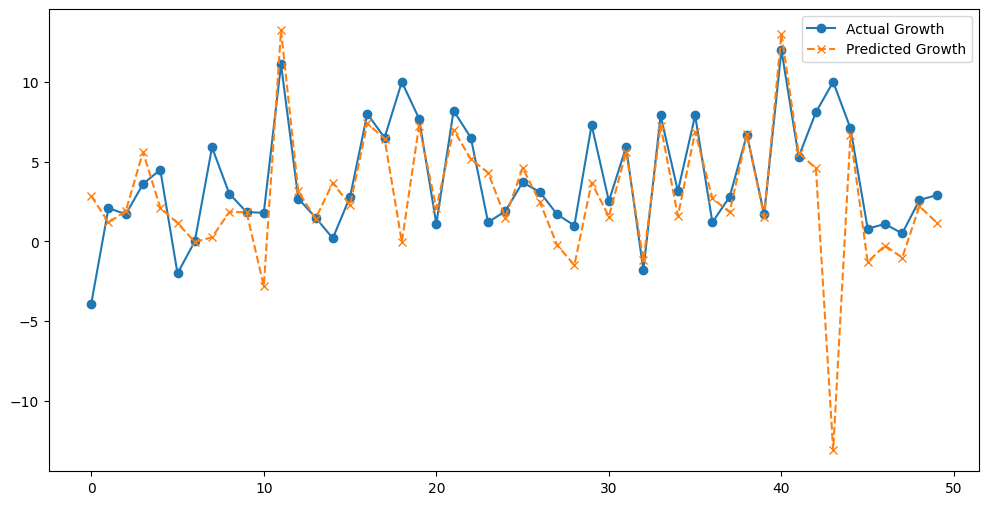

In [38]:
#Visualize Results

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Growth', marker='o')
plt.plot(y_pred, label='Predicted Growth', linestyle='dashed', marker='x')
plt.legend()
plt.show()

In [40]:
#Compute SHAP Feature Importance

explainer = shap.Explainer(xgb_model, X_test)
shap_values = explainer(X_test)

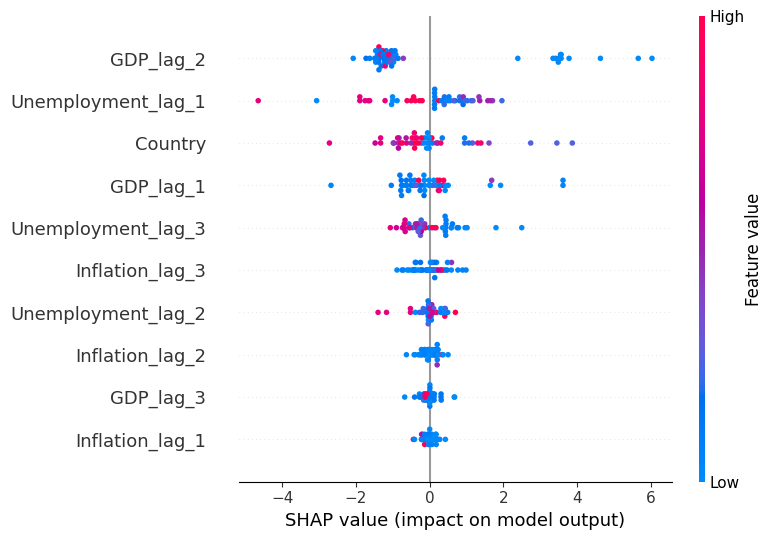

In [41]:
# Visualize feature importance
shap.summary_plot(shap_values, X_test)

In [42]:
#Predict Next Year's Economic Growth for a Specific Country

def predict_next_year(country_name, gdp_lags, inflation_lags, unemployment_lags):
    # Transform the country name to the encoded value
    if country_name not in le.classes_:
        raise ValueError("Country not found in training data. Please use a valid country name.")

    country_code = le.transform([country_name])[0]

    # Create a dictionary to match the feature names
    latest_data = {'Country': [country_code]}

    for lag in range(1, 4):
        latest_data[f'GDP_lag_{lag}'] = [gdp_lags.get(lag, 0)]  # Default to 0 if missing
        latest_data[f'Inflation_lag_{lag}'] = [inflation_lags.get(lag, 0)]
        latest_data[f'Unemployment_lag_{lag}'] = [unemployment_lags.get(lag, 0)]

    # Convert to DataFrame
    latest_df = pd.DataFrame(latest_data)

    # Ensure correct feature order
    latest_df = latest_df.reindex(columns=features, fill_value=0)

    # Make prediction
    prediction = xgb_model.predict(latest_df)
    return prediction[0]

In [43]:
# prediction

country = input("Enter country name: ")

gdp_lags = {i: float(input(f"Enter GDP ({i} year(s) ago): ")) for i in range(1, 4)}
inflation_lags = {i: float(input(f"Enter Inflation Rate ({i} year(s) ago): ")) for i in range(1, 4)}
unemployment_lags = {i: float(input(f"Enter Unemployment Rate ({i} year(s) ago): ")) for i in range(1, 4)}

predicted_growth = predict_next_year(country, gdp_lags, inflation_lags, unemployment_lags)
print(f'Predicted Economic Growth for {country} next year: {predicted_growth:.2f}%')

Enter country name: India
Enter GDP (1 year(s) ago): 3000
Enter GDP (2 year(s) ago): 2900
Enter GDP (3 year(s) ago): 2800
Enter Inflation Rate (1 year(s) ago): 5
Enter Inflation Rate (2 year(s) ago): 5.3
Enter Inflation Rate (3 year(s) ago): 5.5
Enter Unemployment Rate (1 year(s) ago): 5.2
Enter Unemployment Rate (2 year(s) ago): 5.4
Enter Unemployment Rate (3 year(s) ago): 5.5
Predicted Economic Growth for India next year: 3.28%
